# CarsiDock 虚拟筛选教程

本 notebook 只保留 **距离矩阵预测 -> 构象搜索恢复** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

In [1]:
import sys
import copy
import warnings
from pathlib import Path
from collections import deque
from scipy.spatial import distance_matrix
from scipy.optimize import differential_evolution

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, compute_rmsd,
    describe_model_parameters, history_frame, load_complex,
    metric_frame, parse_pdb_ids, plot_loss_curves,
)

## 1. 超参数设置

以下超参数控制模型特征维度、训练过程和构象搜索行为。

**关于构象搜索参数的说明：**
- `N_CONFORMERS`: RDKit 生成的初始构象数量，越多则搜索空间越大
- `DE_TOP_K`: 预筛选后保留的最优构象数，只对这些运行耗时的全局优化
- `DE_MAXITER` / `DE_POPSIZE`: differential_evolution 优化器的设置

In [2]:
MAX_DIST = 20.0
POCKET_CUTOFF = 8.0
N_CONFORMERS = 50
DE_MAXITER = 30
DE_POPSIZE = 5
DE_TOP_K = 5
COORD_RECOVERY_STEPS = 2000
COORD_RECOVERY_LR = 0.1
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

display(pd.DataFrame({
    '超参数': ['ATOM_FEAT_DIM', 'HIDDEN_DIM', 'N_EPOCHS', 'LR',
              'MAX_DIST', 'POCKET_CUTOFF', 'N_CONFORMERS',
              'DE_MAXITER', 'DE_POPSIZE', 'DE_TOP_K', 'DEVICE'],
    '值': [ATOM_FEAT_DIM, HIDDEN_DIM, N_EPOCHS, LR,
           MAX_DIST, POCKET_CUTOFF, N_CONFORMERS,
           DE_MAXITER, DE_POPSIZE, DE_TOP_K, str(DEVICE)],
}))

,超参数,值
0,ATOM_FEAT_DIM,10
1,HIDDEN_DIM,128
2,N_EPOCHS,200
3,LR,0.001
4,MAX_DIST,20.0
5,POCKET_CUTOFF,8.0
6,N_CONFORMERS,50
7,DE_MAXITER,30
8,DE_POPSIZE,5
9,DE_TOP_K,5


## 2. 数据加载与特征提取

本节定义以下核心函数：

1. **构象搜索工具函数**（移植自 DiffDock）：
   - `axis_angle_to_matrix()`: Rodrigues 公式
   - `get_rotatable_bonds()`: 获取配体可旋转键
   - `modify_torsion_angles()`: 修改扭转角

2. **数据加载函数**：
   - 加载蛋白口袋和配体
   - 截取 POCKET_CUTOFF 内的口袋原子
   - 计算并截断距离矩阵
   - 保留 RDKit Mol 对象用于构象搜索

In [3]:
def axis_angle_to_matrix(axis_angle):
    """Rodrigues 公式: 轴角向量 -> 旋转矩阵。"""
    axis_angle = np.asarray(axis_angle, dtype=np.float64)
    angle = np.linalg.norm(axis_angle)
    if angle < 1e-8:
        return np.eye(3, dtype=np.float32)
    k = axis_angle / angle
    K = np.array([[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]])
    R = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    return R.astype(np.float32)


def get_rotatable_bonds(mol):
    """获取配体的可旋转键列表（非环单键，不含氢原子）。"""
    rot_bonds = []
    for bond in mol.GetBonds():
        if (bond.GetBondType() == Chem.rdchem.BondType.SINGLE
                and not bond.IsInRing()
                and bond.GetBeginAtom().GetAtomicNum() != 1
                and bond.GetEndAtom().GetAtomicNum() != 1
                and bond.GetBeginAtom().GetDegree() > 1
                and bond.GetEndAtom().GetDegree() > 1):
            rot_bonds.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
    return rot_bonds


def modify_torsion_angles(coords, mol, rot_bonds, delta_angles):
    """通过 BFS + Rodrigues 修改配体扭转角。"""
    new_coords = coords.copy()
    for (u, v), angle in zip(rot_bonds, delta_angles):
        if abs(angle) < 1e-8:
            continue
        visited = set()
        queue = deque([v])
        visited.add(v)
        while queue:
            node = queue.popleft()
            for nb in mol.GetAtomWithIdx(node).GetNeighbors():
                nb_idx = nb.GetIdx()
                if nb_idx != u and nb_idx not in visited:
                    visited.add(nb_idx)
                    queue.append(nb_idx)
        axis = new_coords[v] - new_coords[u]
        axis_norm = np.linalg.norm(axis)
        if axis_norm < 1e-8:
            continue
        rot_mat = axis_angle_to_matrix(axis / axis_norm * angle)
        for idx in visited:
            new_coords[idx] = rot_mat @ (new_coords[idx] - new_coords[u]) + new_coords[u]
    return new_coords


def build_carsidock_data(pdbid):
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_mol, lig_mol = cplx["prot_mol"], cplx["lig_mol"]
    prot_coords, lig_coords = cplx["prot_coords"], cplx["lig_coords"]

    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)

    lig_center = lig_coords.mean(axis=0)
    prot_dists = np.linalg.norm(prot_coords - lig_center, axis=1)
    pocket_mask = prot_dists < POCKET_CUTOFF
    if pocket_mask.sum() < 3:
        top_k = min(20, len(prot_coords))
        pocket_idx = np.argsort(prot_dists)[:top_k]
        prot_coords = prot_coords[pocket_idx]
        prot_feats = prot_feats[pocket_idx]
    else:
        prot_coords = prot_coords[pocket_mask]
        prot_feats = prot_feats[pocket_mask]

    dist_mat = distance_matrix(prot_coords, lig_coords).astype(np.float32)
    dist_mat = np.clip(dist_mat, 0, MAX_DIST)
    return prot_feats, lig_feats, prot_coords, lig_coords, dist_mat, lig_mol


pdb_ids = parse_pdb_ids(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(pdb_ids)} 个复合物")

all_data = []
all_mols = []
for pdbid in sorted(pdb_ids):
    prot_f, lig_f, prot_c, lig_c, dist_mat, lig_mol = build_carsidock_data(pdbid)
    all_data.append((prot_f, lig_f, prot_c, lig_c, dist_mat))
    all_mols.append(lig_mol)

print(f"成功加载 {len(all_data)} 个复合物")

sample = all_data[0]
display(pd.DataFrame({
    '数据': ['prot_feats', 'lig_feats', 'prot_coords', 'lig_coords', 'dist_matrix'],
    '形状': [str(sample[0].shape), str(sample[1].shape), str(sample[2].shape),
            str(sample[3].shape), str(sample[4].shape)]
}))

从 CoreSet.dat 读取到 20 个复合物
成功加载 20 个复合物


,数据,形状
0,prot_feats,"(89, 10)"
1,lig_feats,"(36, 10)"
2,prot_coords,"(89, 3)"
3,lig_coords,"(36, 3)"
4,dist_matrix,"(89, 36)"


## 3. 数据集与数据加载器

`lig_mol`（RDKit Mol 对象）单独存储，不经过 DataLoader 的 collate，通过返回索引 `idx` 在需要时从 `mol_list` 取回。

In [4]:
class CarsiDockDataset(Dataset):
    def __init__(self, data_list, mol_list):
        self.data = data_list
        self.mols = mol_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        prot_f, lig_f, prot_c, lig_c, dist_mat = self.data[idx]
        return (torch.FloatTensor(prot_f),
                torch.FloatTensor(lig_f),
                torch.FloatTensor(prot_c),
                torch.FloatTensor(lig_c),
                torch.FloatTensor(dist_mat),
                idx)


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_idx, test_idx = indices[:split], indices[split:]

train_data = [all_data[i] for i in train_idx]
train_mols = [all_mols[i] for i in train_idx]
test_data = [all_data[i] for i in test_idx]
test_mols = [all_mols[i] for i in test_idx]

train_dataset = CarsiDockDataset(train_data, train_mols)
test_dataset = CarsiDockDataset(test_data, test_mols)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '总计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}',
             f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,总计,20,100%


## 4. 模型架构

本节只保留 **CarsiDock 的技术路线**：模型先预测距离矩阵，再用构象搜索恢复化学合理的配体构象。

```
蛋白特征 + 配体特征 + 蛋白/配体坐标
  -> 蛋白/配体嵌入 -> 成对距离拼接 -> Pair MLP
  -> 预测距离矩阵 (N_p, N_l)
  -> RDKit 构象生成 + 差分进化全局优化
  -> 最优构象坐标 (N_l, 3)
```

**核心创新**：结合距离矩阵预测（神经网络）和构象搜索（差分进化），保证输出的化学合理性。

In [5]:
class ToyCarsiDock(nn.Module):
    """保留距离矩阵预测路线，骨架只用 Linear + ReLU。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.prot_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.lig_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.pair_embed = build_mlp(hidden_dim * 2, hidden_dim, hidden_dim)
        self.dist_head = build_mlp(hidden_dim, hidden_dim, 1)

    def forward(self, prot_f, lig_f):
        prot_h = self.prot_embed(prot_f)
        lig_h = self.lig_embed(lig_f)
        prot_h_exp = prot_h.unsqueeze(1).expand(-1, lig_h.size(0), -1)
        lig_h_exp = lig_h.unsqueeze(0).expand(prot_h.size(0), -1, -1)
        pair_h = self.pair_embed(torch.cat([prot_h_exp, lig_h_exp], dim=-1))
        pred_dist = self.dist_head(pair_h).squeeze(-1)
        return pred_dist.clamp(min=0.0, max=MAX_DIST)


model = ToyCarsiDock(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,prot_embed.0.weight,"(128, 10)",1280
1,prot_embed.0.bias,"(128,)",128
2,prot_embed.2.weight,"(128, 128)",16384
3,prot_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,pair_embed.0.weight,"(128, 256)",32768
9,pair_embed.0.bias,"(128,)",128


In [6]:
def recover_coords_conformer_search(lig_mol, pred_dist, prot_coords, n_confs=N_CONFORMERS):
    """从预测距离矩阵恢复配体坐标——使用 Vina-like 构象搜索。

    核心思想（参考 CarsiDock docking_utils.py）：
      1. RDKit 力场生成多个化学合理的初始构象
      2. 获取可旋转键，定义 6+N 维搜索空间（平移+旋转+扭转）
      3. 预筛选：快速打分选出 top-K 候选构象
      4. differential_evolution 全局优化每个候选构象
      5. 选择全局最优构象作为对接结果
    """
    n_lig = pred_dist.shape[1]
    pocket_center = prot_coords.mean(axis=0)

    mol = copy.deepcopy(lig_mol)
    mol_h = Chem.AddHs(mol)
    conf_ids = AllChem.EmbedMultipleConfs(
        mol_h, numConfs=n_confs, randomSeed=SEED, clearConfs=True, numThreads=0
    )
    mol_h = Chem.RemoveHs(mol_h)

    if len(conf_ids) == 0:
        return _recover_gradient(pred_dist, prot_coords, n_lig)

    rot_bonds = get_rotatable_bonds(mol_h)
    n_tor = len(rot_bonds)
    bounds = ([(-5.0, 5.0)] * 3 + [(-np.pi, np.pi)] * 3 + [(-np.pi, np.pi)] * n_tor)

    candidates = []
    for conf_id in range(mol_h.GetNumConformers()):
        conf = mol_h.GetConformer(conf_id)
        init_coords = np.array([conf.GetAtomPosition(i)
                                for i in range(mol_h.GetNumAtoms())], dtype=np.float32)
        if init_coords.shape[0] != n_lig:
            continue
        centered = init_coords - init_coords.mean(axis=0)
        quick_coords = centered + pocket_center
        quick_dist = np.clip(distance_matrix(prot_coords, quick_coords).astype(np.float32), 0, MAX_DIST)
        candidates.append((np.mean((quick_dist - pred_dist) ** 2), centered))

    if len(candidates) == 0:
        return _recover_gradient(pred_dist, prot_coords, n_lig)

    candidates.sort(key=lambda x: x[0])
    top_candidates = candidates[:DE_TOP_K]

    best_score = float('inf')
    best_coords = None

    for _, centered_coords in top_candidates:
        def _score_pose(params, _centered=centered_coords):
            tr = np.array(params[:3], dtype=np.float32)
            rot = np.array(params[3:6], dtype=np.float64)
            tor = np.array(params[6:], dtype=np.float64)
            coords = _centered.copy()
            if n_tor > 0:
                coords = modify_torsion_angles(coords, mol_h, rot_bonds, tor)
            rot_mat = axis_angle_to_matrix(rot)
            coords = (rot_mat @ coords.T).T + pocket_center + tr
            curr_dist = np.clip(distance_matrix(prot_coords, coords).astype(np.float32), 0, MAX_DIST)
            return np.mean((curr_dist - pred_dist) ** 2)

        result = differential_evolution(
            _score_pose, bounds, maxiter=DE_MAXITER, popsize=DE_POPSIZE,
            seed=SEED, tol=1e-4, polish=False
        )
        if result.fun < best_score:
            best_score = result.fun
            p = result.x
            coords = centered_coords.copy()
            if n_tor > 0:
                coords = modify_torsion_angles(coords, mol_h, rot_bonds, p[6:])
            rot_mat = axis_angle_to_matrix(np.array(p[3:6], dtype=np.float64))
            best_coords = (rot_mat @ coords.T).T + pocket_center + np.array(p[:3], dtype=np.float32)

    return best_coords if best_coords is not None else _recover_gradient(pred_dist, prot_coords, n_lig)


@torch.enable_grad()
def _recover_gradient(pred_dist, prot_coords, n_lig, n_steps=COORD_RECOVERY_STEPS, lr=COORD_RECOVERY_LR):
    """梯度下降坐标恢复（TankBind 方法，用作 fallback）。"""
    pred_dist_t = torch.FloatTensor(pred_dist)
    prot_coords_t = torch.FloatTensor(prot_coords)
    center = prot_coords_t.mean(dim=0)
    lig_coords_t = nn.Parameter(5.0 * (2.0 * torch.rand(n_lig, 3) - 1.0) + center)
    opt = torch.optim.Adam([lig_coords_t], lr=lr)
    for _ in range(n_steps):
        opt.zero_grad()
        curr_dist = torch.cdist(prot_coords_t.unsqueeze(0), lig_coords_t.unsqueeze(0)).squeeze(0)
        ((torch.clamp(curr_dist, max=MAX_DIST) - pred_dist_t) ** 2).mean().backward()
        opt.step()
    return lig_coords_t.detach().numpy()

## 5. 训练

训练目标：最小化预测距离矩阵与真实距离矩阵之间的 MSE 损失。

In [7]:
model = ToyCarsiDock(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for prot_f, lig_f, prot_c, lig_c, dist_mat, _idx in train_loader:
        prot_f = prot_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_c = prot_c.squeeze(0).to(DEVICE)
        lig_c = lig_c.squeeze(0).to(DEVICE)
        dist_mat = dist_mat.squeeze(0).to(DEVICE)
        pred_dist = model(prot_f, lig_f)
        loss = criterion(pred_dist, dist_mat)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for prot_f, lig_f, prot_c, lig_c, dist_mat, _idx in test_loader:
            prot_f = prot_f.squeeze(0).to(DEVICE)
            lig_f = lig_f.squeeze(0).to(DEVICE)
            prot_c = prot_c.squeeze(0).to(DEVICE)
            lig_c = lig_c.squeeze(0).to(DEVICE)
            dist_mat = dist_mat.squeeze(0).to(DEVICE)
            val_losses.append(criterion(model(prot_f, lig_f), dist_mat).item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 43.9191 | Val Loss: 7.4435
Epoch  20/200 | Train Loss: 5.8569 | Val Loss: 4.4573
Epoch  40/200 | Train Loss: 5.4559 | Val Loss: 6.0617
Epoch  60/200 | Train Loss: 5.6621 | Val Loss: 4.7098
Epoch  80/200 | Train Loss: 5.2863 | Val Loss: 4.8013
Epoch 100/200 | Train Loss: 5.2624 | Val Loss: 4.9628
Epoch 120/200 | Train Loss: 5.2979 | Val Loss: 5.1424
Epoch 140/200 | Train Loss: 5.6880 | Val Loss: 4.8378
Epoch 160/200 | Train Loss: 5.2658 | Val Loss: 4.6731
Epoch 180/200 | Train Loss: 5.5550 | Val Loss: 4.5534
Epoch 200/200 | Train Loss: 5.4004 | Val Loss: 4.5813


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

In [8]:
print("在测试集上评估距离矩阵预测 + 构象搜索恢复...")
model.eval()
rmsds_conformer = []

with torch.no_grad():
    for prot_f, lig_f, prot_c, lig_c, _dist_mat, idx in test_loader:
        prot_f = prot_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_c_np = prot_c.squeeze(0).numpy()
        lig_c_np = lig_c.squeeze(0).numpy()
        pred_dist = model(prot_f, lig_f).cpu().numpy()
        lig_mol = test_dataset.mols[idx.item()]
        coords_conf = recover_coords_conformer_search(lig_mol, pred_dist, prot_c_np, n_confs=N_CONFORMERS)
        rmsds_conformer.append(compute_rmsd(coords_conf, lig_c_np))

rmsds_conformer = np.asarray(rmsds_conformer, dtype=np.float32)
success_rate = float((rmsds_conformer < 2.0).mean() * 100.0)
display(metric_frame([("RMSD < 2A", f"{success_rate:.1f}%")]))

在测试集上评估距离矩阵预测 + 构象搜索恢复...


,指标,值
0,RMSD < 2A,0.0%


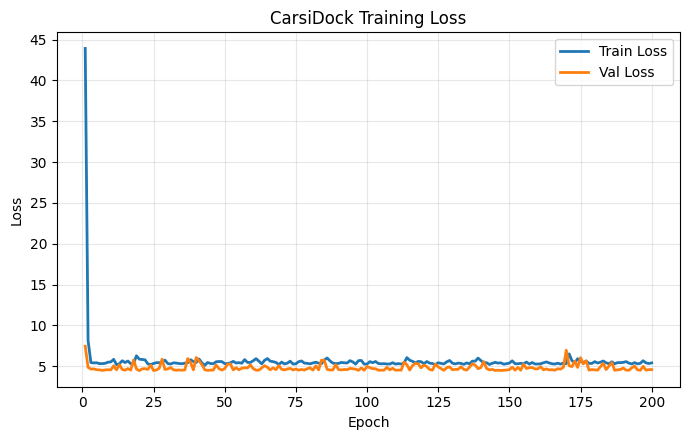

In [9]:
plot_loss_curves(train_loss_history, val_loss_history, title="CarsiDock Training Loss")

## 总结

- 技术路线：保留 CarsiDock 的"距离矩阵预测 -> 构象搜索恢复"路线。
- 教学骨架：统一为 `nn.Linear() + nn.ReLU()` 的简单 MLP。
- 训练输出：统一展示 train / val loss history。
- 主指标：`RMSD < 2A`。